In [ ]:
# 05 — Model Comparison & Hand-off (Member 2 - Smit)

import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import config as C
from predict import (load_model, load_test_set, predict, class_names,
                     feature_columns, load_background, explain_ready)
from evaluation import evaluate, print_report

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 220)

In [ ]:
## 1. Generate the report

import subprocess
subprocess.run([sys.executable, "build_report.py"], cwd="../src")

CompletedProcess(args=['d:\\Collage\\SEM 2\\Deep Learning  Generative AI\\Group Project\\h9dlga-financial-health\\.venv\\Scripts\\python.exe', 'build_report.py'], returncode=0)

In [4]:
comparison = pd.read_csv(C.COMPARISON_CSV)
paper = pd.read_csv(C.RESULTS_DIR / "model_comparison_paper.csv")
print("Publication-ready table (Table II in the paper)\n")
print(paper.to_string(index=False))

Publication-ready table (Table II in the paper)

             Model      F1-macro  AUC-ROC  F1 At-Risk  F1 Distressed  F1 Healthy  Train (s)  Params
LogisticRegression 0.737 ± 0.000    0.907       0.718          0.854       0.638        0.0      72
           XGBoost 0.847 ± 0.001    0.963       0.835          0.897       0.810        0.6 2156224
               MLP 0.789 ± 0.015    0.941       0.778          0.877       0.713       35.7   40195
    TabTransformer 0.754 ± 0.011    0.932       0.737          0.862       0.664       40.8   65431


In [ ]:
## 2. RQ1 — statistical verdict

x = comparison[comparison.model == "XGBoost"].iloc[0]
t = comparison[comparison.model == "TabTransformer"].iloc[0]

gap = t.f1_macro_mean - x.f1_macro_mean
pooled = np.sqrt(x.f1_macro_std**2 + t.f1_macro_std**2)

print(f"XGBoost         {x.f1_macro_mean:.4f} ± {x.f1_macro_std:.4f}")
print(f"TabTransformer  {t.f1_macro_mean:.4f} ± {t.f1_macro_std:.4f}")
print(f"\ndifference = {gap:+.4f}   pooled std = {pooled:.4f}")

if abs(gap) < max(pooled, 0.01):
    print("\nVERDICT: within noise — no evidence either architecture wins.")
elif gap > 0:
    print("\nVERDICT: TabTransformer outperforms gradient boosting.")
else:
    print("\nVERDICT: gradient boosting outperforms TabTransformer.")
    print("This is a legitimate finding and is reported as such.")

XGBoost         0.8473 ± 0.0011
TabTransformer  0.7540 ± 0.0112

difference = -0.0933   pooled std = 0.0113

VERDICT: gradient boosting outperforms TabTransformer.
This is a legitimate finding and is reported as such.


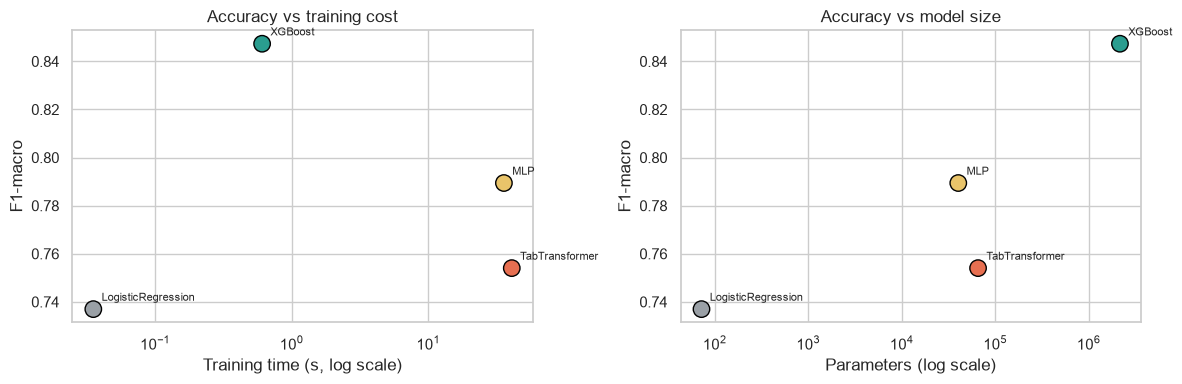

saved -> results/figures/accuracy_vs_cost.png


In [ ]:
## 3. Cost of accuracy


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pal = {"LogisticRegression": "#9aa0a6", "XGBoost": "#2a9d8f",
       "MLP": "#e9c46a", "TabTransformer": "#e76f51"}
colors = [pal[m] for m in comparison.model]

axes[0].scatter(comparison.train_seconds_mean, comparison.f1_macro_mean,
                s=140, c=colors, edgecolor="black", zorder=3)
for _, r in comparison.iterrows():
    axes[0].annotate(r.model, (r.train_seconds_mean, r.f1_macro_mean),
                     textcoords="offset points", xytext=(6, 6), fontsize=8)
axes[0].set(xscale="log", xlabel="Training time (s, log scale)",
            ylabel="F1-macro", title="Accuracy vs training cost")

axes[1].scatter(comparison.n_params_mean, comparison.f1_macro_mean,
                s=140, c=colors, edgecolor="black", zorder=3)
for _, r in comparison.iterrows():
    axes[1].annotate(r.model, (r.n_params_mean, r.f1_macro_mean),
                     textcoords="offset points", xytext=(6, 6), fontsize=8)
axes[1].set(xscale="log", xlabel="Parameters (log scale)",
            ylabel="F1-macro", title="Accuracy vs model size")
plt.tight_layout()
plt.savefig(C.FIGURES_DIR / "accuracy_vs_cost.png", dpi=300, bbox_inches="tight")
plt.show()
print("saved -> results/figures/accuracy_vs_cost.png")

In [ ]:
## 4. Error analysis

preds = pd.read_csv(C.PREDICTIONS_CSV)
pred_cols = [c for c in preds.columns if c.startswith("pred_")]

preds["n_unique"] = preds[pred_cols].nunique(axis=1)
preds["all_agree"] = preds.n_unique == 1
print(f"all models agree on {preds.all_agree.mean()*100:.1f}% of test rows")

best_col = "pred_XGBoost" if "pred_XGBoost" in preds.columns else pred_cols[0]
conf_col = best_col.replace("pred_", "conf_")
preds["correct"] = preds[best_col] == preds.label

print("\nAccuracy by confidence decile (best model):")
band = pd.qcut(preds[conf_col], 5, labels=["lowest", "low", "mid", "high", "highest"])
print(preds.groupby(band, observed=True)["correct"].agg(["mean", "count"]).round(3).to_string())

all models agree on 71.9% of test rows

Accuracy by confidence decile (best model):
               mean  count
conf_XGBoost              
lowest        0.616    276
low           0.797    276
mid           0.909    275
high          0.975    276
highest       0.996    276


In [8]:
# Confident errors — the highest-value cases for narrative evaluation
wrong = preds[~preds.correct].nlargest(10, conf_col)
print("Most confident mistakes (ideal SHAP case studies)\n")
print(wrong[["company_id", "year", "label", best_col, conf_col]].to_string(index=False))
wrong.to_csv(C.RESULTS_DIR / "confident_errors.csv", index=False)

Most confident mistakes (ideal SHAP case studies)

company_id  year      label pred_XGBoost  conf_XGBoost
      FTEK  2022    At-Risk      Healthy        0.9865
       UGI  2023    At-Risk   Distressed        0.9696
       ZVO  2021    At-Risk   Distressed        0.9629
       XRX  2024    At-Risk   Distressed        0.9618
     BRK-A  2022    At-Risk   Distressed        0.9585
      FTEK  2023    At-Risk      Healthy        0.9546
      MRAM  2023    At-Risk      Healthy        0.9536
      YELP  2024    At-Risk      Healthy        0.9481
      CDXC  2024 Distressed      Healthy        0.9393
       RAD  2021    At-Risk      Healthy        0.9389


In [ ]:
## 5. Hand-off validation

subprocess.run([sys.executable, "validate_handoff.py"], cwd="../src")

CompletedProcess(args=['d:\\Collage\\SEM 2\\Deep Learning  Generative AI\\Group Project\\h9dlga-financial-health\\.venv\\Scripts\\python.exe', 'validate_handoff.py'], returncode=0)

In [10]:
pkg = explain_ready("xgboost")

print("keys:", list(pkg.keys()))
print(f"\nmodel        : {pkg['model_name']}")
print(f"test rows    : {len(pkg['raw'])}")
print(f"matrix       : {pkg['X'].shape}")
print(f"classes      : {pkg['class_names']}")
print(f"background   : {pkg['background'].shape}")

keys: ['model', 'model_name', 'raw', 'X', 'y_true', 'y_true_labels', 'y_pred', 'y_pred_labels', 'proba', 'background', 'class_names', 'feature_columns']

model        : xgboost
test rows    : 1379
matrix       : (1379, 23)
classes      : ['At-Risk', 'Distressed', 'Healthy']
background   : (100, 23)


In [11]:
# Live SHAP on a single company — the exact pattern Member 3 will use
import shap

explainer = shap.TreeExplainer(pkg["model"])
shap_values = explainer.shap_values(pkg["X"].head(50))
shap_values = np.asarray(shap_values)
print("SHAP array shape:", shap_values.shape, "(rows, features, classes)")

i = 0
pred_idx = pkg["y_pred"][i]
row_shap = shap_values[i, :, pred_idx]
top = (pd.Series(row_shap, index=pkg["feature_columns"])
         .sort_values(key=abs, ascending=False).head(5))

print(f"\nCompany   : {pkg['raw'].company_id.iloc[i]} (FY{pkg['raw'].year.iloc[i]})")
print(f"True      : {pkg['y_true_labels'][i]}")
print(f"Predicted : {pkg['y_pred_labels'][i]} "
      f"(confidence {pkg['proba'][i].max():.3f})")
print("\nTop SHAP contributions — these become the LLM prompt:")
for feat, val in top.items():
    print(f"  {feat:<24} {val:+.4f}")

SHAP array shape: (50, 23, 3) (rows, features, classes)

Company   : A21 (FY2021)
True      : At-Risk
Predicted : At-Risk (confidence 0.496)

Top SHAP contributions — these become the LLM prompt:
  asset_turnover           -0.3272
  debt_to_equity           +0.2552
  cost_growth              -0.1772
  revenue_growth           -0.1451
  ebit_margin              +0.0844


## 7. summary

| File | Purpose |
|---|---|
| `data/splits.json` | company IDs per fold — evaluate on the identical test set |
| `models/preprocessor.joblib` | replay identical preprocessing on any row |
| `models/label_encoder.joblib` | class index ↔ name mapping |
| `models/feature_columns.json` | exact column order — SHAP breaks if it drifts |
| `models/xgboost_model.json` | best model checkpoint |
| `models/mlp_model.pt`, `tabtransformer_model.pt` | neural checkpoints |
| `results/background_sample.csv` | 100 training rows for DeepSHAP baselines |
| `results/test_predictions.csv` | per-row predictions and confidences |
| `results/confident_errors.csv` | high-value SHAP case studies |
| `src/predict.py` | single entry point |
